"Una universidad online tiene la siguiente base de datos con 7 registros correspondientes a
las notas de los alumnos en 2 asignaturas de un programa de estudios. A partir de dicha
información se requiere agrupar a los alumnos en 2 agrupaciones exclusivas empleando el
algoritmo k-means y la medida de distancia Euclídeana."

In [5]:
import pandas as pd
import numpy as np

# Dataset
data = {
    'Alumno': ['Alumno 1','Alumno 2','Alumno 3','Alumno 4','Alumno 5',
               'Alumno 6','Alumno 7'],
    'Asignatura_1': [1, 1.5, 3, 5.5, 3.5, 4.5, 3.5],
    'Asignatura_2': [1, 2, 4, 7, 5, 5, 4.5]
}

df = pd.DataFrame(data)

# Paso 1 - Definir K
K = 2

# Paso 2 - Elegir centroides iniciales
puntos = df[['Asignatura_1', 'Asignatura_2']].values
centroides = df[['Asignatura_1', 'Asignatura_2']].sample(n=K, random_state=42).values

# Paso 6 - Loop hasta converger
for iteracion in range(100):
    print(f"\n--- Iteración {iteracion + 1} ---")

    # Paso 3 y 4 - Calcular distancias y asignar grupos
    asignaciones = []
    dist_c1, dist_c2 = [], []

    for punto in puntos:
        distancias = [np.sqrt(np.sum((punto - c) ** 2)) for c in centroides]
        grupo = np.argmin(distancias)
        asignaciones.append(grupo)
        dist_c1.append(round(distancias[0], 4))
        dist_c2.append(round(distancias[1], 4))

    df['Dist_C1'] = dist_c1
    df['Dist_C2'] = dist_c2
    df['Grupo']   = asignaciones
    print(df[['Alumno', 'Dist_C1', 'Dist_C2', 'Grupo']])

    # Paso 5 - Recalcular centroides
    nuevos_centroides = []
    for n in range(K):
        grupo_k = df[df['Grupo'] == n][['Asignatura_1', 'Asignatura_2']]
        nuevos_centroides.append(grupo_k.mean().values.tolist())

    nuevos_centroides = np.array(nuevos_centroides)
    print(f"\nCentroides: {nuevos_centroides.round(4)}")

    # Verificar convergencia
    if np.allclose(centroides, nuevos_centroides):
        print(f"\n Convergió en la iteración {iteracion + 1}")
        break

    centroides = nuevos_centroides

# Resultado final
print("\nGRUPOS FINALES")
print(df[['Alumno', 'Asignatura_1', 'Asignatura_2', 'Grupo']])


--- Iteración 1 ---
     Alumno  Dist_C1  Dist_C2  Grupo
0  Alumno 1   0.0000   1.1180      0
1  Alumno 2   1.1180   0.0000      1
2  Alumno 3   3.6056   2.5000      1
3  Alumno 4   7.5000   6.4031      1
4  Alumno 5   4.7170   3.6056      1
5  Alumno 6   5.3151   4.2426      1
6  Alumno 7   4.3012   3.2016      1

Centroides: [[1.     1.    ]
 [3.5833 4.5833]]

--- Iteración 2 ---
     Alumno  Dist_C1  Dist_C2  Grupo
0  Alumno 1   0.0000   4.4175      0
1  Alumno 2   1.1180   3.3187      0
2  Alumno 3   3.6056   0.8250      1
3  Alumno 4   7.5000   3.0845      1
4  Alumno 5   4.7170   0.4249      1
5  Alumno 6   5.3151   1.0069      1
6  Alumno 7   4.3012   0.1179      1

Centroides: [[1.25 1.5 ]
 [4.   5.1 ]]

--- Iteración 3 ---
     Alumno  Dist_C1  Dist_C2  Grupo
0  Alumno 1   0.5590   5.0804      0
1  Alumno 2   0.5590   3.9825      0
2  Alumno 3   3.0516   1.4866      1
3  Alumno 4   6.9507   2.4207      1
4  Alumno 5   4.1608   0.5099      1
5  Alumno 6   4.7762   0.5099      

Usando scikit learn


In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Dataset
data = {
    'Alumno': ['Alumno 1','Alumno 2','Alumno 3','Alumno 4','Alumno 5','Alumno 6','Alumno 7'],
    'Asignatura_1': [1, 1.5, 3, 5.5, 3.5, 4.5, 3.5],
    'Asignatura_2': [1, 2, 4, 7, 5, 5, 4.5]
}

df = pd.DataFrame(data)

# Paso 1 - Definir K
K = 2

# Pasos 2 al 6 - KMeans hace todo internamente
puntos = df[['Asignatura_1', 'Asignatura_2']].values

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(puntos)

# Resultados
df['Grupo'] = kmeans.labels_

print("=== CENTROIDES FINALES ===")
print(kmeans.cluster_centers_)

print("\n=== GRUPOS FINALES ===")
print(df[['Alumno', 'Asignatura_1', 'Asignatura_2', 'Grupo']])

=== CENTROIDES FINALES ===
[[4.   5.1 ]
 [1.25 1.5 ]]

=== GRUPOS FINALES ===
     Alumno  Asignatura_1  Asignatura_2  Grupo
0  Alumno 1           1.0           1.0      1
1  Alumno 2           1.5           2.0      1
2  Alumno 3           3.0           4.0      0
3  Alumno 4           5.5           7.0      0
4  Alumno 5           3.5           5.0      0
5  Alumno 6           4.5           5.0      0
6  Alumno 7           3.5           4.5      0


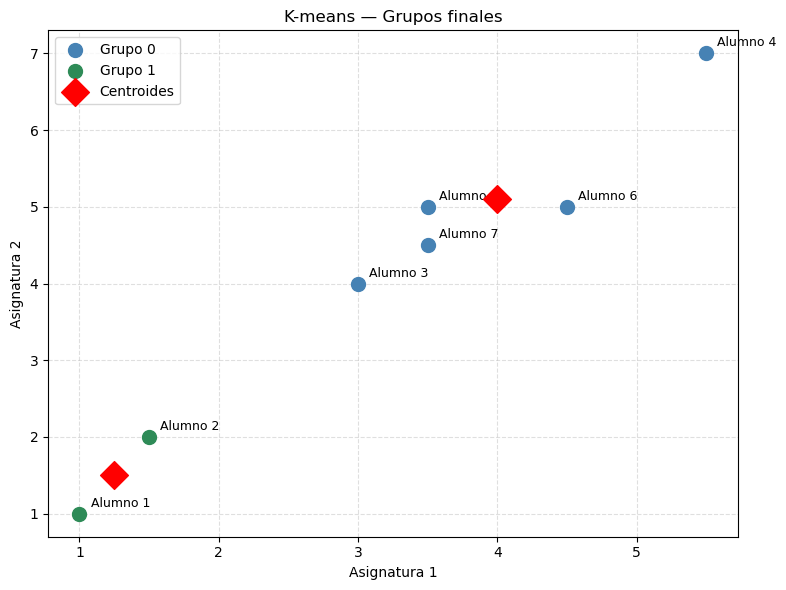

In [11]:
import matplotlib.pyplot as plt
import mplcursors

colores = {0: 'steelblue', 1: 'seagreen'}

fig, ax = plt.subplots(figsize=(8, 6))

scatters = []

for grupo, datos in df.groupby('Grupo'):
    sc = ax.scatter(datos['Asignatura_1'], datos['Asignatura_2'],
               color=colores[grupo], s=100, label=f'Grupo {grupo}', zorder=3)
    scatters.append((sc, list(datos['Alumno'])))
    for _, fila in datos.iterrows():
        ax.annotate(fila['Alumno'], (fila['Asignatura_1'], fila['Asignatura_2']),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)

ax.scatter(centroides[:,0], centroides[:,1], color='red', s=200, marker='D', label='Centroides', zorder=4)
ax.set_xlabel('Asignatura 1')
ax.set_ylabel('Asignatura 2')
ax.set_title('K-means — Grupos finales')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

# Tooltip al pasar el mouse
for sc, nombres in scatters:
    cursor = mplcursors.cursor(sc, hover=True)
    cursor.connect("add", lambda sel, n=nombres: sel.annotation.set_text(
        f"{n[sel.index]}\n({sel.target[0]:.1f}, {sel.target[1]:.1f})"
    ))

plt.tight_layout()
plt.show()

In [1]:
#pip install mplcursors

K=1 → inercia: 39.1429
K=2 → inercia: 9.8250
K=3 → inercia: 2.5000
K=4 → inercia: 1.2917
K=5 → inercia: 0.6667
K=6 → inercia: 0.1250


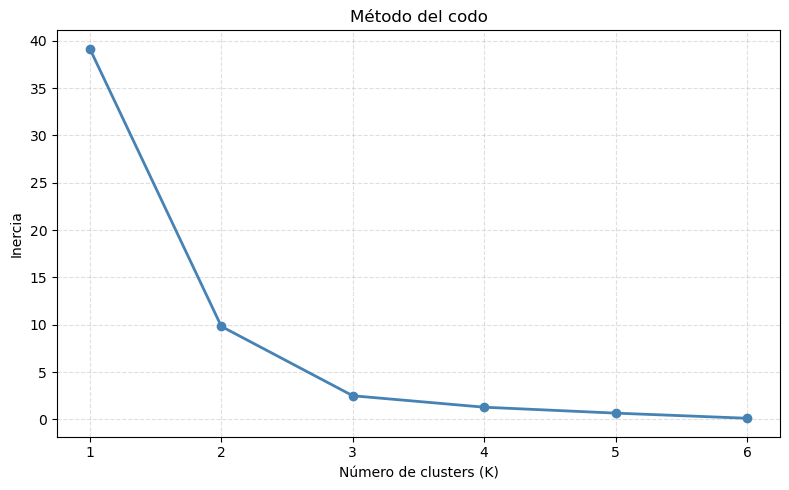

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dataset
data = {
    'Alumno': ['Alumno 1','Alumno 2','Alumno 3','Alumno 4','Alumno 5','Alumno 6','Alumno 7'],
    'Asignatura_1': [1, 1.5, 3, 5.5, 3.5, 4.5, 3.5],
    'Asignatura_2': [1, 2, 4, 7, 5, 5, 4.5]
}

df = pd.DataFrame(data)
puntos = df[['Asignatura_1', 'Asignatura_2']].values

# Calcular inercia para K del 1 al 6
inercias = []
rango_k = range(1, 7)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(puntos)
    inercias.append(kmeans.inertia_)
    print(f"K={k} → inercia: {kmeans.inertia_:.4f}")

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Dataset
data = {
    'Alumno': ['Alumno 1','Alumno 2','Alumno 3','Alumno 4','Alumno 5','Alumno 6','Alumno 7'],
    'Asignatura_1': [1, 1.5, 3, 5.5, 3.5, 4.5, 3.5],
    'Asignatura_2': [1, 2, 4, 7, 5, 5, 4.5]
}

df = pd.DataFrame(data)
puntos = df[['Asignatura_1', 'Asignatura_2']].values

# Silhouette para cada K
print("=== SILHOUETTE SCORE POR K ===")
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(puntos)
    score = silhouette_score(puntos, labels)
    print(f"K={k} → silhouette score: {score:.4f}")

# Detalle por alumno con K=2
print("\n=== SILHOUETTE POR ALUMNO (K=2) ===")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(puntos)
scores_individuales = silhouette_samples(puntos, labels)

df['Grupo']      = labels
df['Silhouette'] = scores_individuales.round(4)
print(df[['Alumno', 'Grupo', 'Silhouette']])

=== SILHOUETTE SCORE POR K ===
K=2 → silhouette score: 0.6326
K=3 → silhouette score: 0.5556
K=4 → silhouette score: 0.3598
K=5 → silhouette score: 0.1636
K=6 → silhouette score: 0.1133

=== SILHOUETTE POR ALUMNO (K=2) ===
     Alumno  Grupo  Silhouette
0  Alumno 1      1      0.7803
1  Alumno 2      1      0.7198
2  Alumno 3      0      0.3831
3  Alumno 4      0      0.5623
4  Alumno 5      0      0.6728
5  Alumno 6      0      0.6779
6  Alumno 7      0      0.6317


Implementarlo desde cero paso a paso
Usarlo con scikit-learn
Elegir K con el método del codo
Validarlo con silhouette score